# **Exploratory Data Analysis (EDA) on Numerical Food Data**

Objective:
The purpose of this exploratory data analysis (EDA) is to understand
the structure, quality, and characteristics of the nutritional and
textual food datasets used for NOVA food processing classification.

This analysis aims to answer the following questions:



*    What does the dataset look like?
*    Are there missing values or inconsistencies?
*   Are the NOVA classes balanced?
*   Which nutritional features appear important?
*   How do nutrient distributions vary across NOVA classes?
*   Are features correlated with each other?
*   What patterns exist in the textual data?
*   How separable are the classes in feature/embedding space?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv("102_Nutrients_Data.csv")

**What does data look like?**

In [ ]:
data.shape

(2970, 103)

In [ ]:
data.head()

,Protein,Total Fat,Carbohydrate,Energy,Alcohol,Water,Caffeine,Theobromine,"Sugars, total","Fiber, total dietary",...,(+)-Gallocatechin,Total flavonoids,Total anthocyanidins,Total catechins (monomeric flavan-3-ols only),Total flavan-3-ols,Total flavanones,Total flavones,Total flavonols,Total isoflavones,novaclass
0,1.03,4.38,6.89,70.0,0.0,87.50,0.0,0.0,6.89,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,3.28,1.91,4.85,50.0,0.0,89.25,0.0,0.0,5.08,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,3.15,3.25,4.80,61.0,0.0,88.13,0.0,0.0,5.05,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,3.10,3.46,4.46,61.0,0.0,88.20,0.0,0.0,4.46,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,3.14,3.24,4.79,61.0,0.0,87.87,0.0,0.0,5.04,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [ ]:
data.sample(5)

,Protein,Total Fat,Carbohydrate,Energy,Alcohol,Water,Caffeine,Theobromine,"Sugars, total","Fiber, total dietary",...,(+)-Gallocatechin,Total flavonoids,Total anthocyanidins,Total catechins (monomeric flavan-3-ols only),Total flavan-3-ols,Total flavanones,Total flavones,Total flavonols,Total isoflavones,novaclass
49,4.84,3.14,13.54,100.0,0.0,77.48,0.0,0.0,13.54,0.0,...,0.0,0.00,0.0,0.00,0.00,0.0,0.00,0.00,0.0,4
309,3.50,11.00,23.60,207.0,0.0,61.00,0.0,0.0,21.22,0.7,...,0.0,0.00,0.0,0.00,0.00,0.0,0.00,0.00,0.0,4
1366,4.45,21.90,42.48,374.0,0.0,30.01,8.0,89.0,13.69,2.9,...,0.0,3.00,0.0,2.87,2.87,0.0,0.00,0.13,0.0,4
2403,2.20,4.20,10.40,88.0,0.0,81.00,0.0,0.0,3.64,0.4,...,0.0,9.53,0.0,0.00,0.00,0.0,0.01,9.52,0.0,4
2807,12.20,0.50,41.10,241.0,0.0,3.10,3142.0,0.0,0.00,0.0,...,0.0,0.00,0.0,0.00,0.00,0.0,0.00,0.00,0.0,1


In [ ]:
data.columns

Index(['Protein', 'Total Fat', 'Carbohydrate', 'Energy', 'Alcohol', 'Water',
       'Caffeine', 'Theobromine', 'Sugars, total', 'Fiber, total dietary',
       ...
       '(+)-Gallocatechin', 'Total flavonoids', 'Total anthocyanidins',
       'Total catechins (monomeric flavan-3-ols only)', 'Total flavan-3-ols',
       'Total flavanones', 'Total flavones', 'Total flavonols',
       'Total isoflavones', 'novaclass'],
      dtype='object', length=103)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2970 entries, 0 to 2969
Columns: 103 entries, Protein to novaclass
dtypes: float64(102), int64(1)
memory usage: 2.3 MB


In [ ]:
data.describe()

,Protein,Total Fat,Carbohydrate,Energy,Alcohol,Water,Caffeine,Theobromine,"Sugars, total","Fiber, total dietary",...,(+)-Gallocatechin,Total flavonoids,Total anthocyanidins,Total catechins (monomeric flavan-3-ols only),Total flavan-3-ols,Total flavanones,Total flavones,Total flavonols,Total isoflavones,novaclass
count,2970.000000,2970.000000,2970.000000,2970.000000,2970.000000,2970.000000,2970.000000,2970.000000,2970.000000,2970.000000,...,2970.000000,2970.000000,2970.000000,2970.000000,2970.000000,2970.000000,2970.000000,2970.000000,2970.000000,2970.000000
mean,6.709074,9.877902,30.716303,232.993939,0.096296,50.682064,7.482492,11.142761,13.723811,2.291212,...,0.006593,7.967202,1.508963,2.026532,4.439279,0.375737,0.140758,0.958168,0.544296,3.464983
std,7.552930,15.170097,28.530265,175.170626,1.608298,33.905937,135.045815,60.017926,17.778250,3.916912,...,0.088857,135.878363,11.597435,12.884691,122.155071,3.351397,4.068202,13.366790,6.079686,0.984703
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,1.200000,0.500000,6.952500,68.000000,0.000000,12.320000,0.000000,0.000000,1.550000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
50%,4.550000,3.595000,18.330000,222.000000,0.000000,56.270000,0.000000,0.000000,6.400000,1.200000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000
75%,9.500000,13.600000,54.880000,372.000000,0.000000,83.415000,0.000000,0.000000,19.780000,2.800000,...,0.000000,2.687500,0.000000,0.220000,0.220000,0.000000,0.000000,0.400000,0.000000,4.000000
max,62.880000,100.000000,100.000000,884.000000,37.900000,99.980000,3680.000000,2057.000000,99.800000,77.300000,...,3.210000,7331.200000,324.430000,522.590000,6633.350000,83.180000,216.550000,697.850000,166.940000,4.000000


In [ ]:
data.duplicated().sum()

np.int64(362)

**The dataset contains 362 duplicate entries, which may affect model performance and data quality.**

In [ ]:
corr_matrix= data.corr()

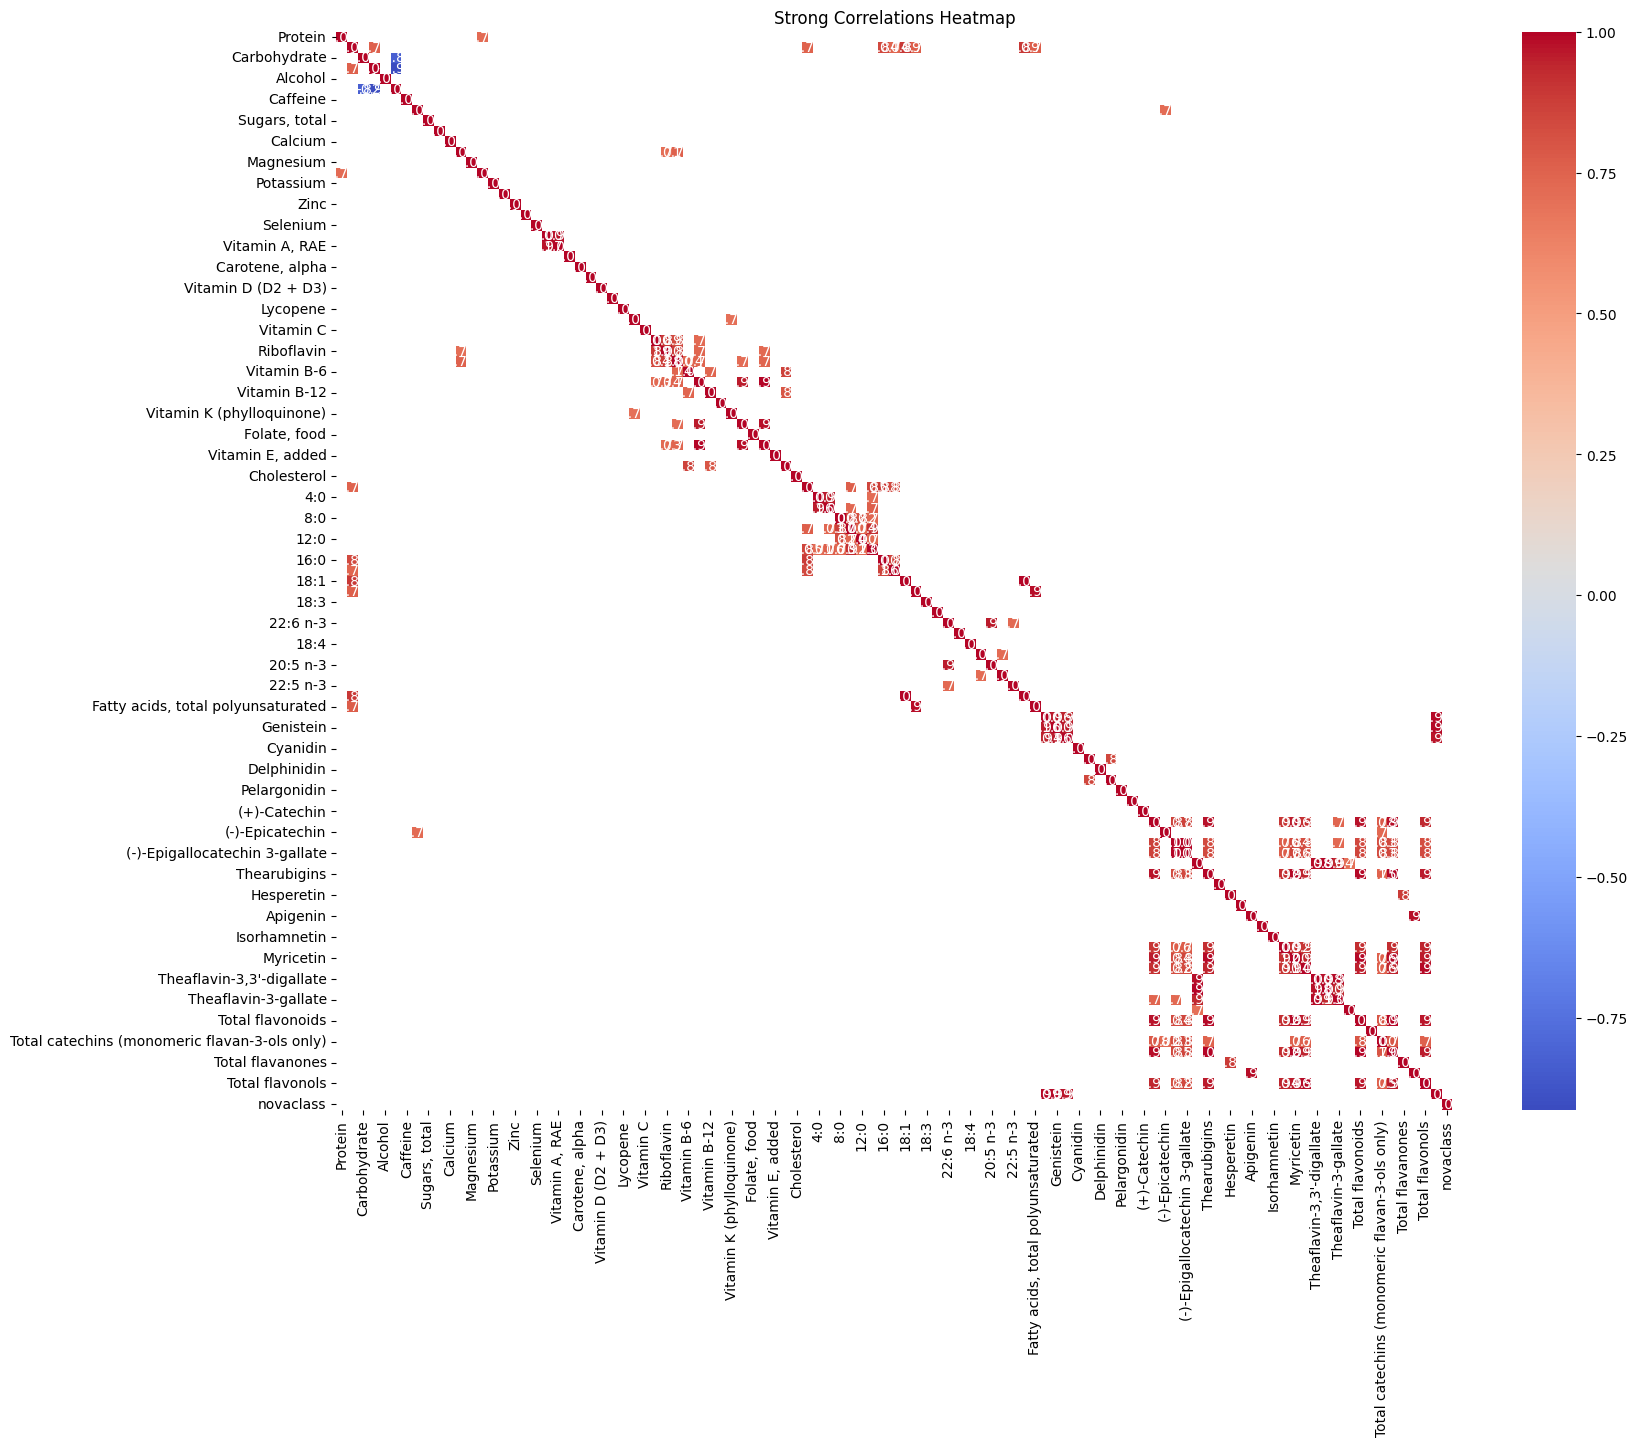

In [ ]:
# Keep only strong correlations
filtered_corr = corr_matrix[
    (corr_matrix >= 0.7) | (corr_matrix <= -0.7)
]

plt.figure(figsize=(18,14))

sns.heatmap(
    filtered_corr,
    cmap='coolwarm',
    annot=True,
    fmt=".2f"
)

plt.title("Strong Correlations Heatmap")
plt.show()

**The correlation heatmap identified several clusters of strongly correlated nutritional variables, particularly among fatty acids, vitamins, and flavonoid compounds. Most features showed weak correlations, indicating high variability in nutritional composition. Only a limited number of negative correlations were observed.**

In [ ]:
corr_matrix["novaclass"].sort_values(ascending=False)

,novaclass
novaclass,1.000000
Carbohydrate,0.305524
Energy,0.249277
"Sugars, total",0.160093
Folic acid,0.147025
...,...
Cyanidin,-0.169866
Total anthocyanidins,-0.176338
Hesperetin,-0.205789
Total flavanones,-0.221325


In [ ]:
# Get correlation with target column
target_corr = corr_matrix["novaclass"].sort_values(ascending=False)

print(target_corr["Total Fat"])

NameError: name 'corr_matrix' is not defined

**Correlation analysis revealed that carbohydrate content, energy, and total sugars were positively associated with higher NOVA classes, while water content and several flavonoid-related compounds showed negative correlations. This suggests that highly processed foods are generally more energy-dense, carbohydrate-rich, and lower in water and naturally occurring bioactive compounds.**

**Check for missing values**

In [ ]:
data.isnull().sum()

,0
Protein,0
Total Fat,0
Carbohydrate,0
Energy,0
Alcohol,0
...,...
Total flavanones,0
Total flavones,0
Total flavonols,0
Total isoflavones,0


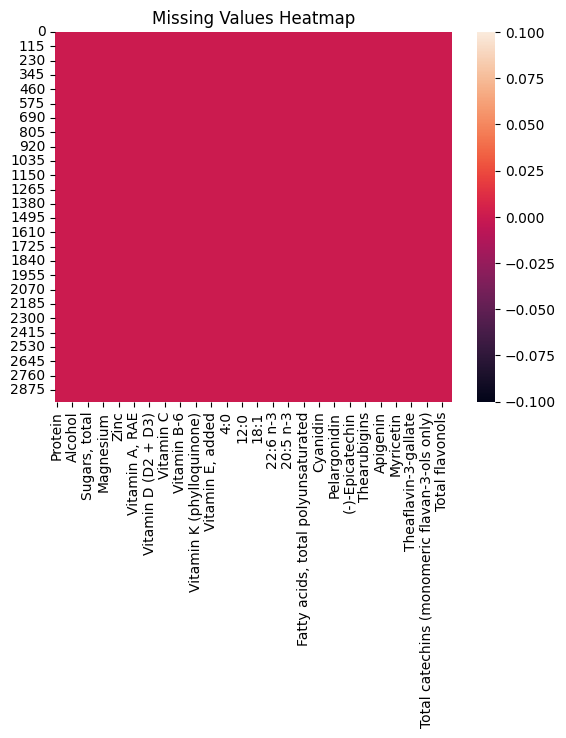

In [ ]:
sns.heatmap(data.isnull())
plt.title("Missing Values Heatmap")
plt.show()

**This shows no missing values in data.**

In [ ]:
data['novaclass'].value_counts()

,count
novaclass,
4,2112
3,466
1,339
2,53


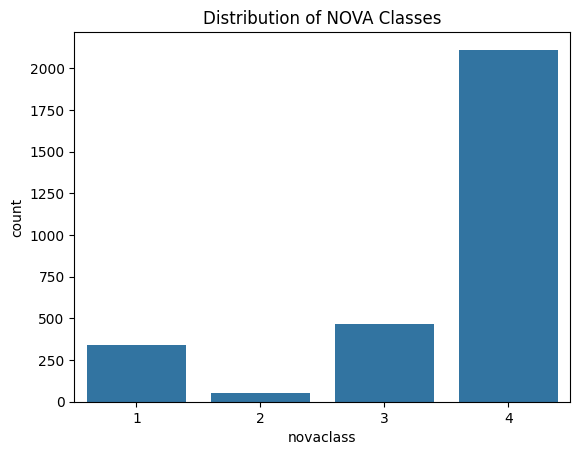

In [ ]:
sns.countplot(x='novaclass', data=data)
plt.title("Distribution of NOVA Classes")
plt.show()

 The dataset appears imbalanced across NOVA classes,
which explains the later use of SMOTE
during model training.

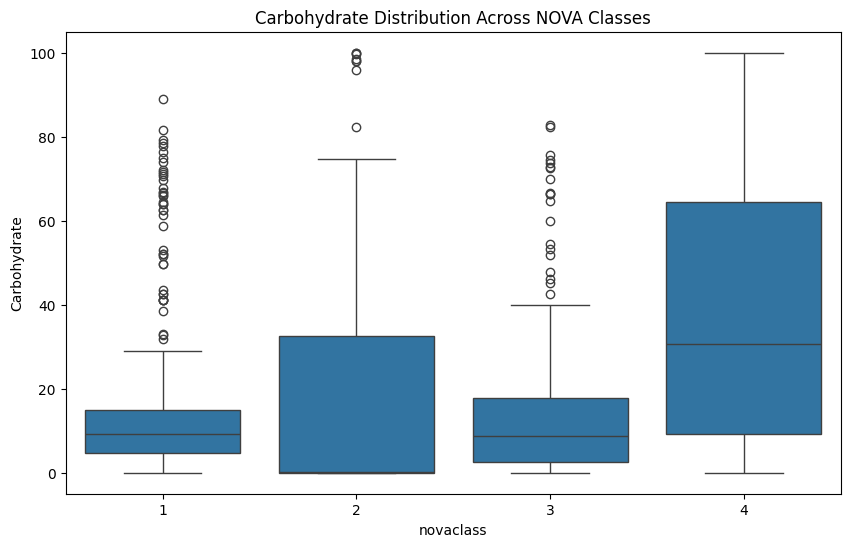

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.boxplot(
    x='novaclass',
    y='Carbohydrate',
    data=data
)

plt.title("Carbohydrate Distribution Across NOVA Classes")
plt.show()

Note: The dots show outliers

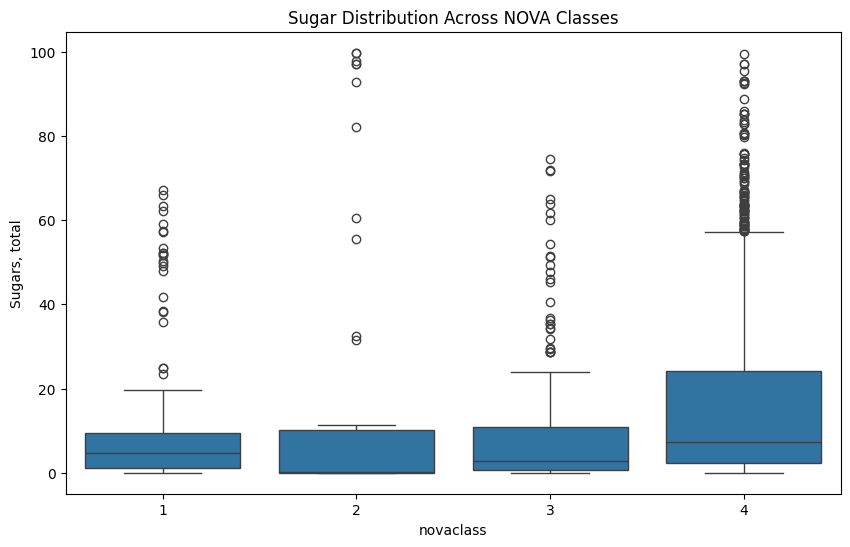

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.boxplot(
    x='novaclass',
    y='Sugars, total',
    data=data
)

plt.title("Sugar Distribution Across NOVA Classes")
plt.show()

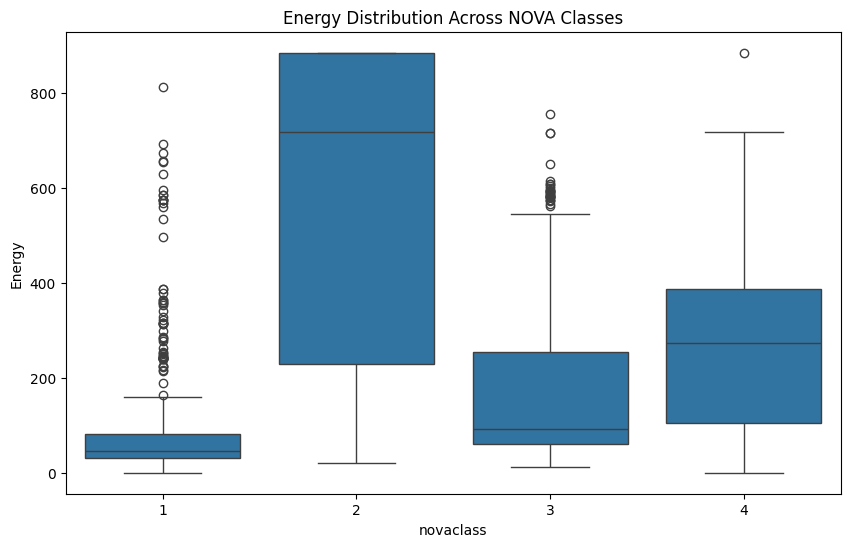

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.boxplot(
    x='novaclass',
    y='Energy',
    data=data
)

plt.title("Energy Distribution Across NOVA Classes")
plt.show()

Means energy alone is not a factor to indicate nova class

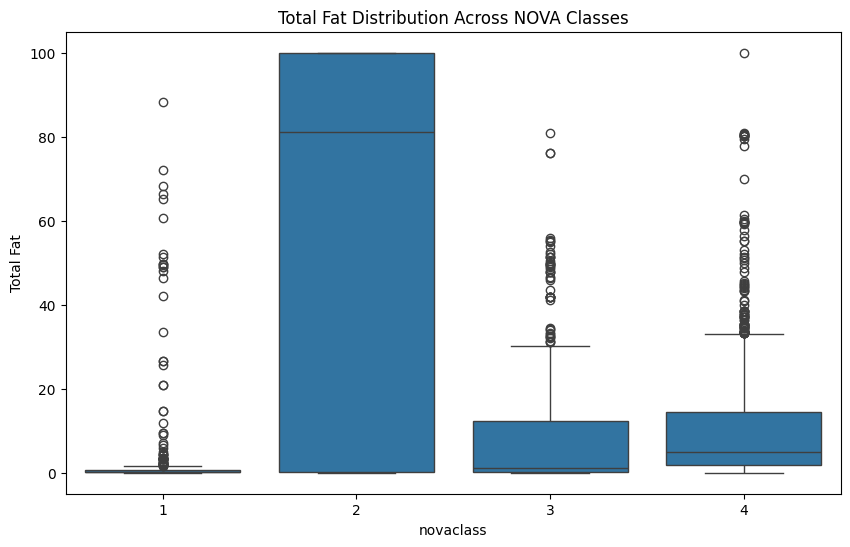

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.boxplot(
    x='novaclass',
    y='Total Fat',
    data=data
)

plt.title("Total Fat Distribution Across NOVA Classes")
plt.show()

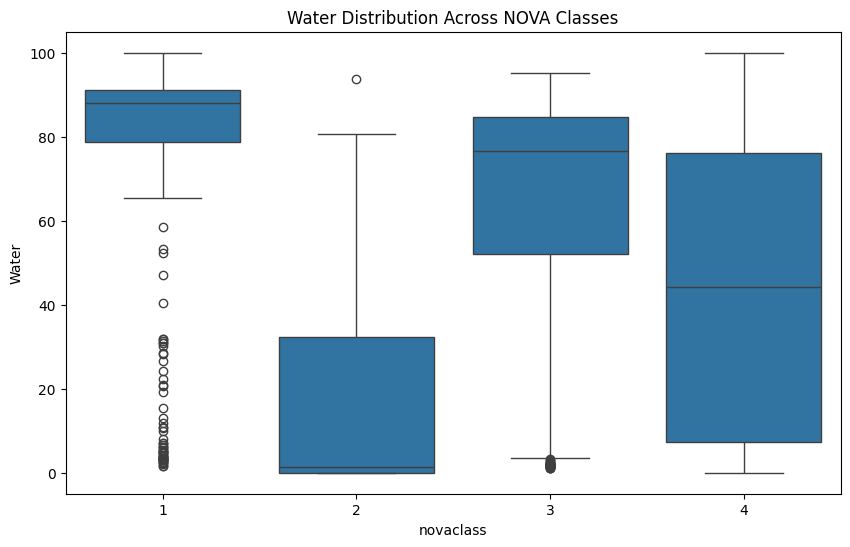

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.boxplot(
    x='novaclass',
    y='Water',
    data=data
)

plt.title("Water Distribution Across NOVA Classes")
plt.show()

In [ ]:
numeric_cols = data.select_dtypes(include=['number']).columns

for col in numeric_cols:

    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[
        (data[col] < lower) |
        (data[col] > upper)
    ]

    print(col, ":", outliers.shape[0])

Protein : 152
Total Fat : 174
Carbohydrate : 0
Energy : 22
Alcohol : 30
Water : 0
Caffeine : 350
Theobromine : 290
Sugars, total : 198
Fiber, total dietary : 248
Calcium : 242
Iron : 249
Magnesium : 325
Phosphorus : 197
Potassium : 216
Sodium : 104
Zinc : 280
Copper : 247
Selenium : 133
Retinol : 399
Vitamin A, RAE : 408
Carotene, beta : 459
Carotene, alpha : 628
Vitamin E (alpha-tocopherol) : 338
Vitamin D (D2 + D3) : 598
Cryptoxanthin, beta : 634
Lycopene : 259
Lutein + zeaxanthin : 372
Vitamin C : 436
Thiamin : 285
Riboflavin : 277
Niacin : 269
Vitamin B-6 : 367
Folate, total : 301
Vitamin B-12 : 416
Choline, total : 258
Vitamin K (phylloquinone) : 318
Folic acid : 458
Folate, food : 227
Folate, DFE : 323
Vitamin E, added : 196
Vitamin B-12, added : 353
Cholesterol : 461
Fatty acids, total saturated : 291
4:0 : 664
6:0 : 565
8:0 : 574
10:0 : 434
12:0 : 513
14:0 : 417
16:0 : 259
18:0 : 340
18:1 : 228
18:2 : 301
18:3 : 295
20:4 : 593
22:6 n-3 : 466
16:1 : 428
18:4 : 197
20:1 : 468
20:

In [ ]:
is_outlier_row = pd.Series(False, index=data.index)
numeric_cols = data.select_dtypes(include=['number']).columns

for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Mark rows as True if they are outliers in the current column
    is_outlier_row = is_outlier_row | ((data[col] < lower_bound) | (data[col] > upper_bound))

overall_outlier_rows_count = is_outlier_row.sum()
print(f"Number of rows with at least one outlier across numerical columns: {overall_outlier_rows_count}")
print(f"Percentage of rows with at least one outlier: {(overall_outlier_rows_count / len(data)) * 100:.2f}%")

Number of rows with at least one outlier across numerical columns: 2853
Percentage of rows with at least one outlier: 96.06%


In [ ]:
(outliers.shape[0] / len(data)) * 100

11.414141414141413

To count the number of rows that contain at least one outlier across any numerical column, we can iterate through all numerical columns and mark rows that are outliers in any of them.

In [ ]:
data.select_dtypes(include=['number']).skew().sum()

np.float64(1865.0120876337803)

This shows overall data is right skewed

FINAL ANALYSIS-

*   Data contains **no missing values**
*   The dataset contains **362 duplicate entries**, which may affect model performance and data quality.

*   The correlation heatmap identified several clusters of strongly correlated nutritional variables, particularly among fatty acids, vitamins, and flavonoid compounds. Most features showed weak correlations, indicating high variability in nutritional composition. Only a limited number of negative correlations were observed.

*   Correlation analysis suggests that highly processed foods are generally more energy-dense, carbohydrate-rich, sugar-rich and lower in water and naturally occurring bioactive compounds.


*   The dataset appears **imbalanced across NOVA classes**, which explains the later use of SMOTE during model training.


* A **large no of outliers** throughout.






